In [160]:
import json
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

## Loading, preparing files

### All book ids

In [161]:
def book_id_to_path(id, book_id_to_book, csv_data_directory):
    book_info = book_id_to_book[id]
    start_year = book_info["year_start"]
    end_year = book_info["year_end"]
    source = book_info["source"].lower()

    return Path(csv_data_directory).glob(
        f"*{book_info["parish_normalized"]}/*{start_year}-{end_year}_{source}"
    )

In [162]:
book_ids_df = pd.read_json("outputs/json/book_ids.json", orient="index")
book_ids_df.columns = ["parish_normalized", "year_start", "year_end", "source"]
book_ids_df = book_ids_df.rename_axis("book_id")
book_ids_to_info = book_ids_df.to_dict(orient="index")

id_to_book = book_ids_df.to_dict(orient="index")
book_path_stems = tuple(tuple(i) for i in book_ids_df.index.map(
    lambda x: book_id_to_path(x, id_to_book, "data/migration-data-csv-release-v1")
).to_list())
book_path_stems = pd.DataFrame({"stem": tuple(i[0].stem if len(i) > 0 else None for i in book_path_stems)}, index=book_ids_df.index)

book_to_id = {
    v: k
    for k, v in (
        book_ids_df["parish_normalized"]
        + "_" + book_path_stems["stem"]
    )
    .to_dict()
    .items()
}

### Year overlaps

In [166]:
with open("outputs/json/possible_overlapping_ids2.json", "r") as fp:
    possible_overlaps = json.load(fp)

rows = []
for overlap_type, pairs in possible_overlaps.items():
    for pair in pairs:
        ids = list(pair.keys())
        book_id_a, book_id_b = ids[0], ids[1]
        rows.append(
            {
                "overlap_type": overlap_type,
                "book_id_a": book_id_a,
                "book_id_b": book_id_b,
            }
        )
possible_overlaps_df = pd.DataFrame(rows)

In [167]:
possible_full_overlaps_df = possible_overlaps_df[
    possible_overlaps_df["overlap_type"] == "full"
]
possible_center_overlaps_df = possible_overlaps_df[
    possible_overlaps_df["overlap_type"] == "partial_center"
]
possible_start_or_end_overlaps_df = possible_overlaps_df[
    possible_overlaps_df["overlap_type"] == "partial_left_or_right"
]

no_year_overlaps_df = possible_overlaps_df[
    possible_overlaps_df["overlap_type"] == "no_overlap"
]

### Checked and found overlaps, leftover book pairs with no overlaps

In [168]:
found_overlaps_df = pd.read_json("data/matrices_with_overlap_type.json")
found_overlaps_df["overlap"] = found_overlaps_df["overlap"].apply(lambda x: ", ".join(x))

found_overlaps_df["year_start_a"] = found_overlaps_df["book_id_a"].map(lambda x: book_ids_to_info[x]["year_start"])
found_overlaps_df["year_start_b"] = found_overlaps_df["book_id_b"].map(lambda x: book_ids_to_info[x]["year_start"])

found_overlaps_df["year_end_a"] = found_overlaps_df["book_id_a"].map(lambda x: book_ids_to_info[x]["year_end"])
found_overlaps_df["year_end_b"] = found_overlaps_df["book_id_b"].map(lambda x: book_ids_to_info[x]["year_end"])

found_overlaps_df["parish"] = found_overlaps_df["book_id_a"].map(lambda x: book_ids_to_info[x]["parish_normalized"])

In [169]:
no_found_overlaps_df = book_ids_df[
    (~book_ids_df.index.isin(found_overlaps_df["book_id_a"]))
    & (~book_ids_df.index.isin(found_overlaps_df["book_id_b"]))
]

## Possible overlaps for book pairs according to years

<Axes: xlabel='Book pairs', ylabel='Overlap type'>

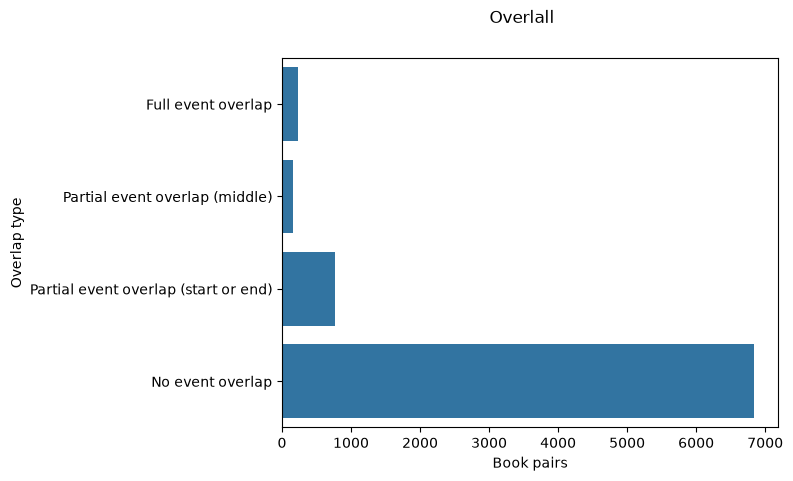

In [170]:
plt.ylabel("Overlap type")
plt.xlabel("Book pairs")
plt.suptitle("Overlall")
sns.barplot(
    y=(
        "Full event overlap",
        "Partial event overlap (middle)",
        "Partial event overlap (start or end)",
        "No event overlap",
    ),
    x=(
        len(possible_full_overlaps_df),
        len(possible_center_overlaps_df),
        len(possible_start_or_end_overlaps_df),
        len(no_year_overlaps_df),
    ),
    orient="h"
)

## Different types of year overlaps

### Out of full year overlaps

In [171]:
full_year_ol_no_event_ol = (
    len(possible_full_overlaps_df)
    - len(found_overlaps_df[found_overlaps_df["years_overlap"] == "full"])
)

In [172]:
full_year_ol_full_event_ol_df = found_overlaps_df[
    (found_overlaps_df["years_overlap"] == "full")
    & (
        (found_overlaps_df["overlap"] == "full")
        | (found_overlaps_df["overlap"] == "full_discontinuous")
    )
]

In [173]:
full_year_ol_partial_b_e_event_ol_df = found_overlaps_df[
    (found_overlaps_df["years_overlap"] == "full")
    & (found_overlaps_df["overlap"].str.contains("full"))
    & (
        (found_overlaps_df["overlap"].str.contains("start"))
        | (found_overlaps_df["overlap"].str.contains("end"))
    )
]
full_year_ol_partial_m_event_ol_df = found_overlaps_df[
    (found_overlaps_df["years_overlap"] == "full")
    & (found_overlaps_df["overlap"].str.contains("full"))
    & (
        (found_overlaps_df["overlap"].str.contains("middle"))
    )
]

<Axes: xlabel='Book pairs', ylabel='Overlap type'>

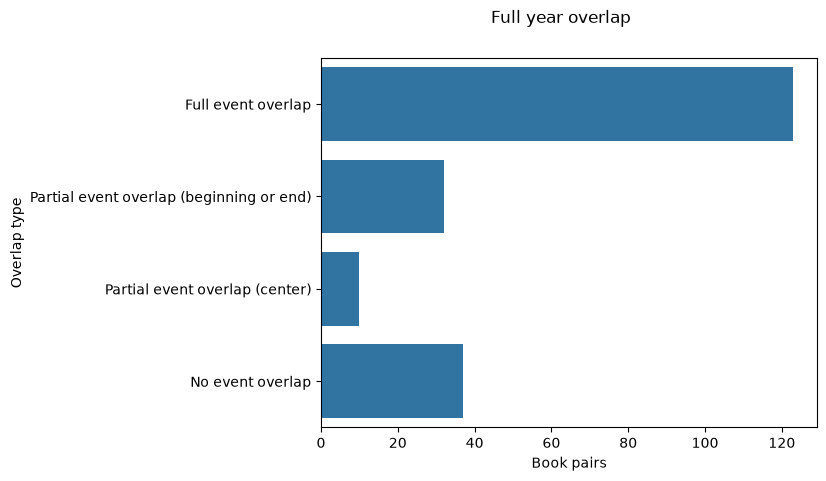

In [174]:
plt.ylabel("Overlap type")
plt.xlabel("Book pairs")
plt.suptitle("Full year overlap")
sns.barplot(
    y=(
        "Full event overlap",
        "Partial event overlap (beginning or end)",
        "Partial event overlap (center)",
        "No event overlap",
    ),
    x=(
        len(full_year_ol_full_event_ol_df),
        len(full_year_ol_partial_b_e_event_ol_df),
        len(full_year_ol_partial_m_event_ol_df),
        full_year_ol_no_event_ol,
    ),
    orient="h"
)

### Years partially overlap (beginning or end of book)

In [175]:
partial_b_e_year_ol_no_event_ol = (
    len(possible_start_or_end_overlaps_df)
    - len(found_overlaps_df[found_overlaps_df["years_overlap"] == "partial_left_or_right"])
)

In [176]:
partial_b_e_year_ol_full_event_ol_df = found_overlaps_df[
    (found_overlaps_df["years_overlap"] == "partial_left_or_right")
    & (
        (found_overlaps_df["overlap"] == "full")
        | (found_overlaps_df["overlap"] == "full_discontinuous")
    )
]

In [177]:
partial_b_e_year_ol_partial_l_e_event_ol_df = found_overlaps_df[
    (found_overlaps_df["years_overlap"] == "partial_left_or_right")
    & (found_overlaps_df["overlap"].str.contains("full"))
    & (
        (found_overlaps_df["overlap"].str.contains("start"))
        | (found_overlaps_df["overlap"].str.contains("end"))
    )
]
partial_b_e_year_ol_partial_m_event_ol_df = found_overlaps_df[
    (found_overlaps_df["years_overlap"] == "partial_left_or_right")
    & (found_overlaps_df["overlap"].str.contains("full"))
    & (
        (found_overlaps_df["overlap"].str.contains("middle"))
    )
]

<Axes: xlabel='Book pairs', ylabel='Overlap type'>

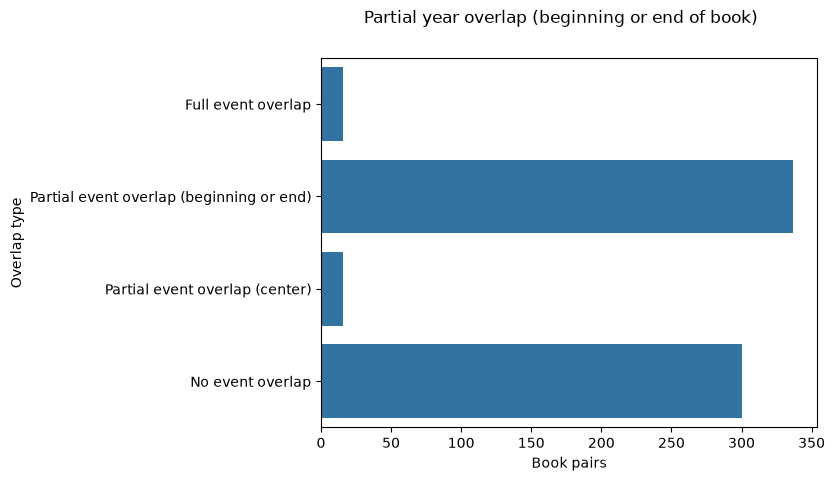

In [178]:
plt.ylabel("Overlap type")
plt.xlabel("Book pairs")
plt.suptitle("Partial year overlap (beginning or end of book)")
sns.barplot(
    y=(
        "Full event overlap",
        "Partial event overlap (beginning or end)",
        "Partial event overlap (center)",
        "No event overlap",
    ),
    x=(
        len(partial_b_e_year_ol_full_event_ol_df),
        len(partial_b_e_year_ol_partial_l_e_event_ol_df),
        len(partial_b_e_year_ol_partial_m_event_ol_df),
        partial_b_e_year_ol_no_event_ol,
    ),
    orient="h"
)

### Years partially overlap (center of book)

In [179]:
partial_c_year_ol_no_event_ol = (
    len(possible_center_overlaps_df)
    - len(found_overlaps_df[found_overlaps_df["years_overlap"] == "partial_center"])
)

In [180]:
partial_c_year_ol_full_event_ol_df = found_overlaps_df[
    (found_overlaps_df["years_overlap"] == "partial_center")
    & (
        (found_overlaps_df["overlap"] == "full")
        | (found_overlaps_df["overlap"] == "full_discontinuous")
    )
]

In [181]:
partial_c_year_ol_partial_l_e_event_ol_df = found_overlaps_df[
    (found_overlaps_df["years_overlap"] == "partial_center")
    & (found_overlaps_df["overlap"].str.contains("full"))
    & (
        (found_overlaps_df["overlap"].str.contains("start"))
        | (found_overlaps_df["overlap"].str.contains("end"))
    )
]
partial_c_year_ol_partial_m_event_ol_df = found_overlaps_df[
    (found_overlaps_df["years_overlap"] == "partial_center")
    & (found_overlaps_df["overlap"].str.contains("full"))
    & (
        (found_overlaps_df["overlap"].str.contains("middle"))
    )
]

<Axes: xlabel='Book pairs', ylabel='Overlap type'>

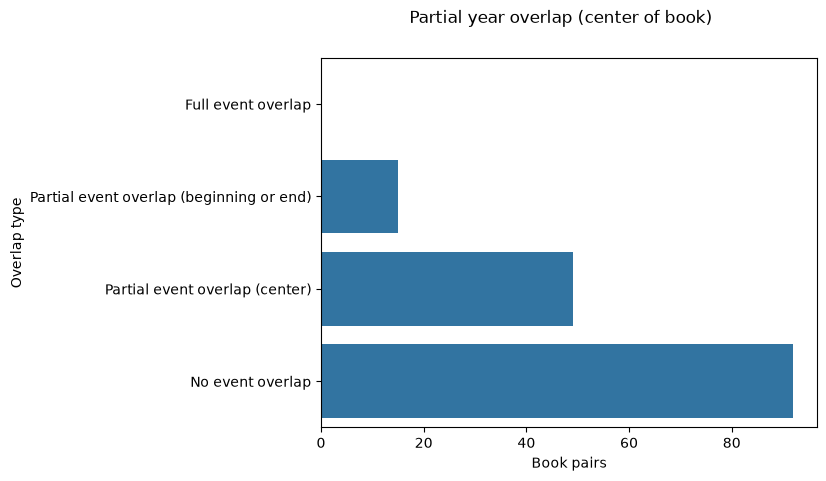

In [182]:
plt.ylabel("Overlap type")
plt.xlabel("Book pairs")
plt.suptitle("Partial year overlap (center of book)")
sns.barplot(
    y=(
        "Full event overlap",
        "Partial event overlap (beginning or end)",
        "Partial event overlap (center)",
        "No event overlap",
    ),
    x=(
        len(partial_c_year_ol_full_event_ol_df),
        len(partial_c_year_ol_partial_l_e_event_ol_df),
        len(partial_c_year_ol_partial_m_event_ol_df),
        partial_c_year_ol_no_event_ol,
    ),
    orient="h"
)

## Book overlaps per year

In [183]:
parish_filter = "ikaalinen"
years = range(1700, 1965, 5)

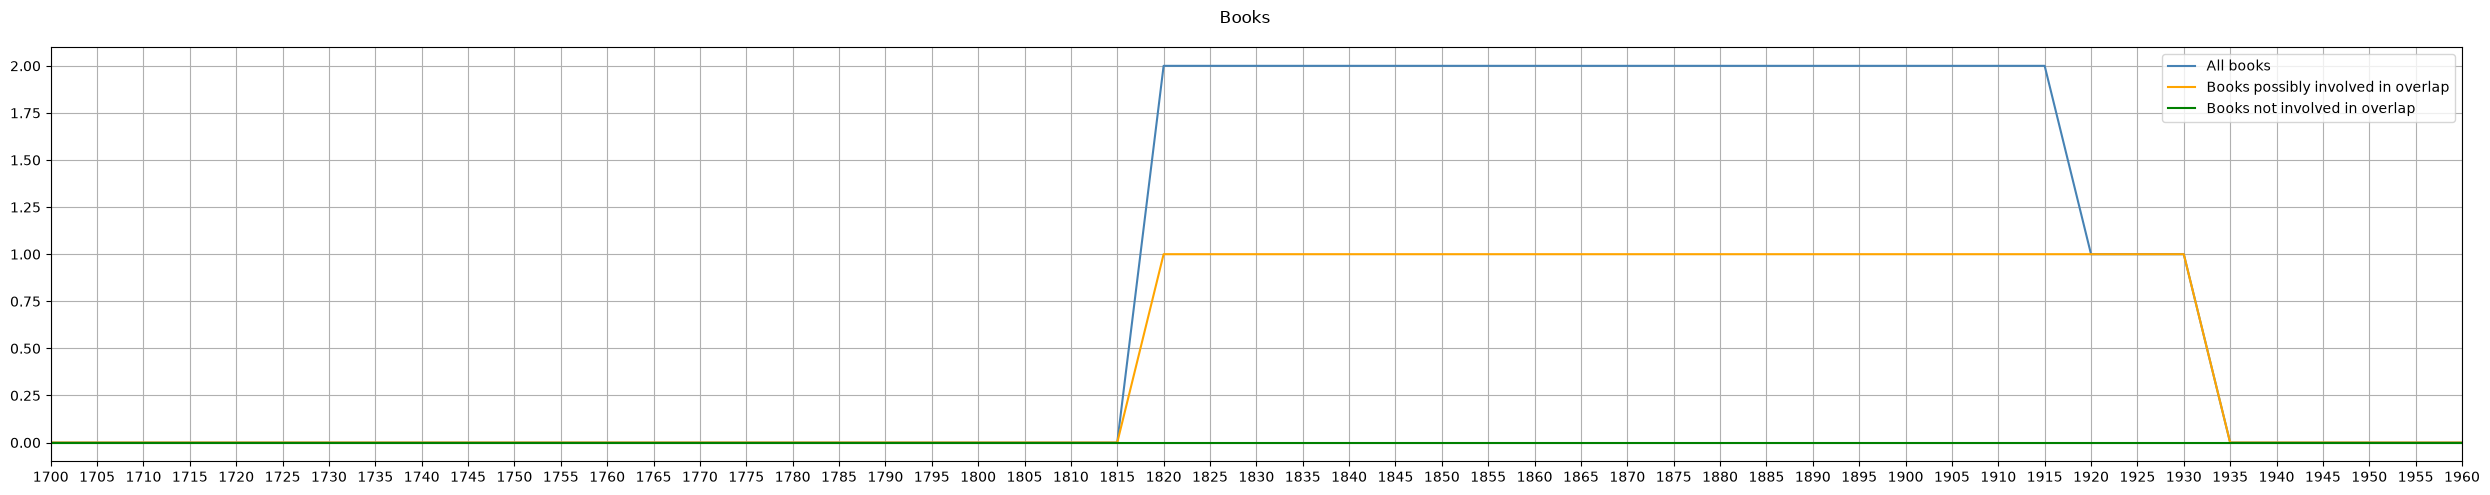

In [184]:
if parish_filter != None:
    book_all_df = book_ids_df[book_ids_df["parish_normalized"] == parish_filter]
    book_overlaps_df = found_overlaps_df[found_overlaps_df["parish"] == parish_filter]
    book_no_year_overlap_df = no_found_overlaps_df[no_found_overlaps_df["parish_normalized"] == parish_filter]
else:
    book_all_df = book_ids_df
    book_overlaps_df = found_overlaps_df
    book_no_year_overlap_df = no_found_overlaps_df

book_all = {}
book_overlaps = {}
book_no_year_overlap = {}
for year in years:
    book_all[year] = len(book_all_df[
            (book_all_df["year_start"] <= year)
            & (book_all_df["year_end"] >= year)
        ])

    book_overlaps[year] = len(
        book_overlaps_df[
            (
                (book_overlaps_df["year_start_a"] <= year)
                & (book_overlaps_df["year_end_a"] >= year)
            ) | (
                (book_overlaps_df["year_start_b"] <= year)
                & (book_overlaps_df["year_end_b"] >= year)
            )
        ]
    )

    book_no_year_overlap[year] = len(
        book_no_year_overlap_df[
            (book_no_year_overlap_df["year_start"] <= year)
            & (book_no_year_overlap_df["year_end"] >= year)
        ]
    )

fig, ax = plt.subplots(1, 1, figsize=(25, 5))

fig.suptitle("Books")

sns.lineplot(book_all, ax=ax, color="steelblue", label="All books")
sns.lineplot(book_overlaps, ax=ax, color="orange", label="Books possibly involved in overlap")
sns.lineplot(book_no_year_overlap, ax=ax, color="green", label="Books not involved in overlap")

ax.set_xticks(years)
ax.grid(True)
ax.set_xlim(years[0], years[-1])
fig.tight_layout()

## Event overlaps per year

In [185]:
base_dir = Path("data/year-predictions")

files = list(base_dir.glob(f"*.jsonl"))

if len(files) == 0:
    print("no events")
else:
    event_year_df = pd.concat(tuple(
        pd.read_json(file_path, lines=True) for file_path in files
    ))
event_year_df = event_year_df[~event_year_df["corrected"].isna() & event_year_df["corrected"].astype(str).str.isnumeric()]
event_year_df["year"] = event_year_df["corrected"]
event_year_df["year"] = event_year_df["year"].astype("int64")
event_year_df["book_id"] = event_year_df["book"].map(lambda x: book_to_id.get(x, 0)).astype("int64")

event_year_df = event_year_df.drop(["corrected"], axis="columns")
event_year_df = event_year_df[(event_year_df["year"] > 1600) & (event_year_df["year"] < 2000)]

### Calculate event count for each page (file)

In [187]:
files = tuple(Path("data/migration-data-csv-release-v1").glob(
    f"*/*/**.csv"
))
file_to_n_rows = {}
for file in tqdm(files):
    file_to_n_rows[file.stem] = file.read_text().count("\n")

100%|██████████| 318514/318514 [00:33<00:00, 9383.62it/s] 


In [188]:
page_to_n_rows = defaultdict(int)
for f, rows in tqdm(file_to_n_rows.items()):
    page_to_n_rows["_".join(f.split("_")[1:-1])] += rows

100%|██████████| 318514/318514 [00:00<00:00, 1309311.83it/s]


In [189]:
key = event_year_df["book"] + "_" + event_year_df["page"].astype(str) + "_" + event_year_df["side"]

event_year_df["events"] = key.map(page_to_n_rows)

In [190]:
event_year_df["parish_normalized"] = event_year_df["book_id"].map(book_ids_df["parish_normalized"])

In [191]:
event_year_df.to_csv("outputs/csv/year_predictions_extended.csv", index=False)

### Events per year

In [205]:
parish_filter = ""
book_ids_filtered_by_parish = book_ids_df[book_ids_df["parish_normalized"].str.contains(parish_filter)].index
bins = list(range(1700, 2005, 5))
xticks = range(1700, 2005, 5)

In [206]:
event_year_df_binned = event_year_df[
    event_year_df["parish_normalized"].str.contains(parish_filter)
][["year", "events", "book_id", "parish_normalized"]].copy()

event_year_df_binned["year_bin"] = pd.cut(
    event_year_df_binned["year"], bins=bins, right=False, labels=bins[:-1]
)

event_year_df_binned_overlaps = event_year_df_binned[
    event_year_df_binned["book_id"].isin(found_overlaps_df["book_id_a"])
    | event_year_df_binned["book_id"].isin(found_overlaps_df["book_id_b"])
]

event_year_df_binned_no_overlaps = event_year_df_binned[
    event_year_df_binned["book_id"].isin(no_found_overlaps_df.index)
]

In [207]:
print(
    f"Total events in migration data:      {sum(event_year_df[event_year_df["book_id"].isin(book_ids_filtered_by_parish)]["events"])}",
    f"Possibly overlapping events removed: {sum(event_year_df[event_year_df["book_id"].isin(book_ids_filtered_by_parish) & event_year_df["book_id"].isin(no_found_overlaps_df.index)]["events"])}",
    sep="\n",
)

Total events in migration data:      5585730
Possibly overlapping events removed: 2870221


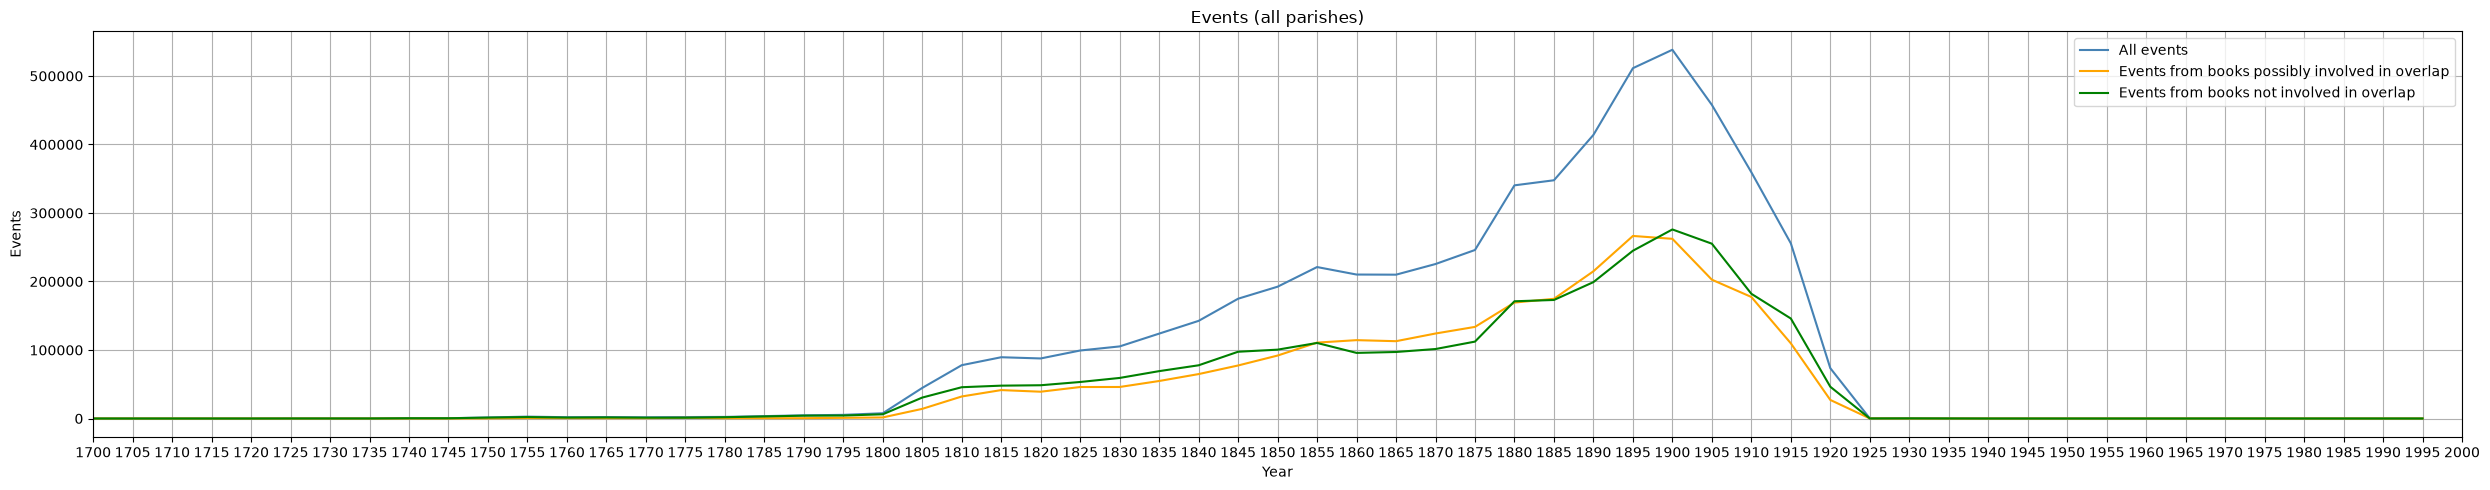

In [208]:
binned = event_year_df_binned.groupby("year_bin", observed=False)["events"].sum().reset_index()
binned_overlaps = event_year_df_binned_overlaps.groupby("year_bin", observed=False)["events"].sum().reset_index()
binned_no_overlaps = event_year_df_binned_no_overlaps.groupby("year_bin", observed=False)["events"].sum().reset_index()

fig, ax = plt.subplots(figsize=(25, 5))
ax.set_title(f"Events{" (" + parish_filter + ")" if parish_filter != "" else " (all parishes)"}")
sns.lineplot(binned, x="year_bin", y="events", ax=ax, color="steelblue", label="All events")
sns.lineplot(data=binned_overlaps, x="year_bin", y="events", ax=ax, color="orange", label="Events from books possibly involved in overlap")
sns.lineplot(data=binned_no_overlaps, x="year_bin", y="events", ax=ax, color="green", label="Events from books not involved in overlap")
ax.grid(True)
ax.set_xlabel("Year")
ax.set_ylabel("Events")
ax.set_xticks(xticks)
ax.set_xlim(bins[0], bins[-1])
fig.tight_layout()

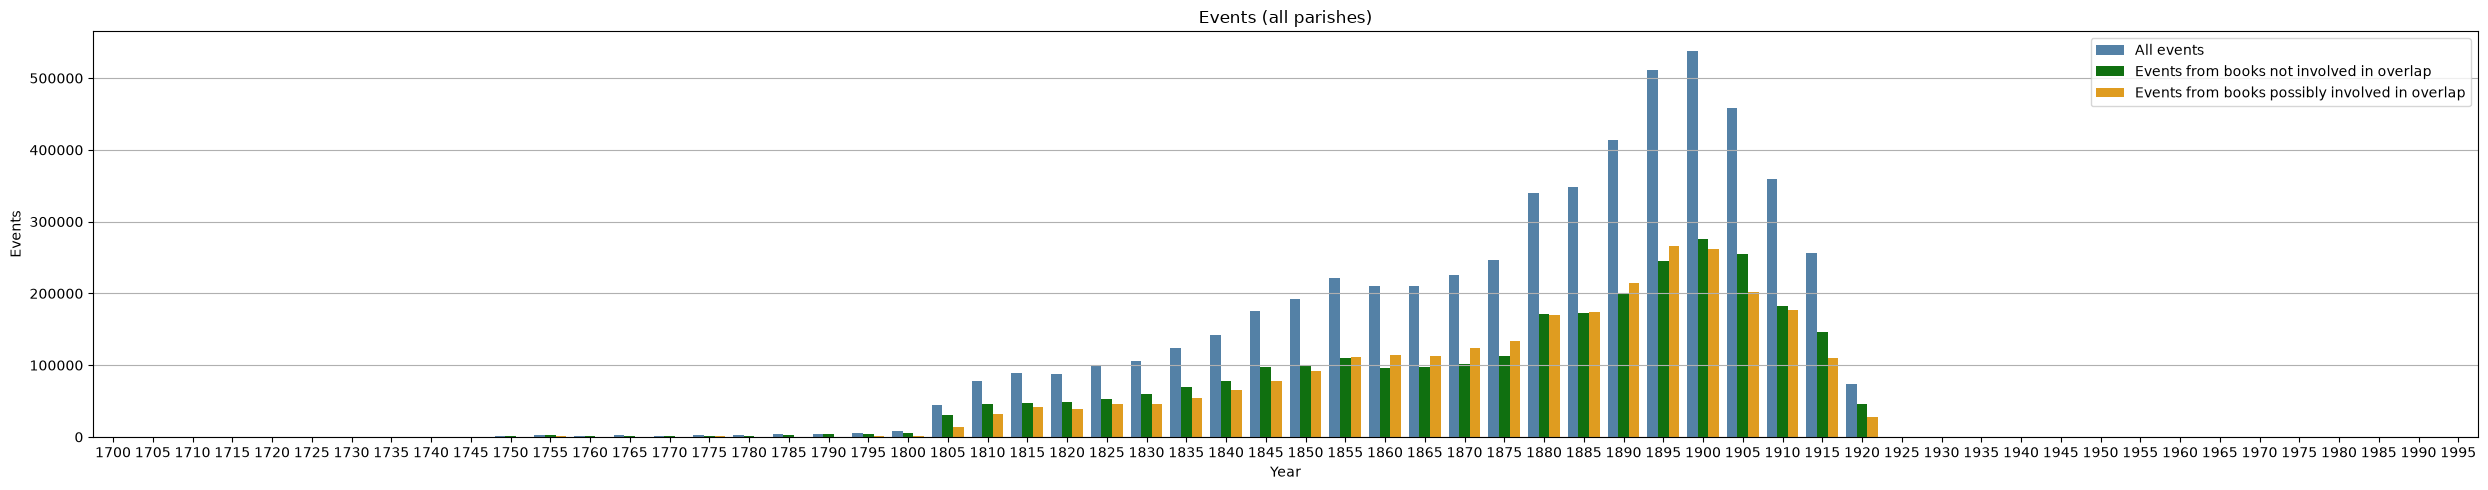

In [209]:
binned["group"] = "All events"
binned_overlaps["group"] = "Events from books possibly involved in overlap"
binned_no_overlaps["group"] = "Events from books not involved in overlap"

combined = pd.concat([binned, binned_no_overlaps, binned_overlaps], ignore_index=True)

fig, ax = plt.subplots(figsize=(25, 5))
ax.set_title(f"Events{" (" + parish_filter + ")" if parish_filter != "" else " (all parishes)"}")
sns.barplot(
    data=combined,
    x="year_bin",
    y="events",
    hue="group",
    ax=ax,
    palette={
        "All events": "steelblue",
        "Events from books not involved in overlap": "green",
        "Events from books possibly involved in overlap": "orange",
    },
)
ax.grid(True, axis="y")
ax.set_xlabel("Year")
ax.set_ylabel("Events")
ax.legend(title=None)
fig.tight_layout()

## Continuing

In [210]:
event_year_df_binned

,year,events,book_id,parish_normalized,year_bin
0,1871,35,27220,kalajoki,1870
1,1871,34,27220,kalajoki,1870
2,1871,35,27220,kalajoki,1870
4,1872,36,27220,kalajoki,1870
5,1872,37,27220,kalajoki,1870
...,...,...,...,...,...
265,1889,12,21920,heinola,1885
266,1889,0,21920,heinola,1885
267,1889,16,21920,heinola,1885
268,1889,0,21920,heinola,1885


In [211]:
pd.Series(event_year_df_binned["parish_normalized"].unique(), name="parish_normalized")

0                     kalajoki
1      turun_linnan_seurakunta
2                     valkeala
3                      tuusula
4                     karttula
                ...           
463                hirvensalmi
464                raippaluoto
465                  aanekoski
466                 miehikkala
467                   kuusjoki
Name: parish_normalized, Length: 468, dtype: str

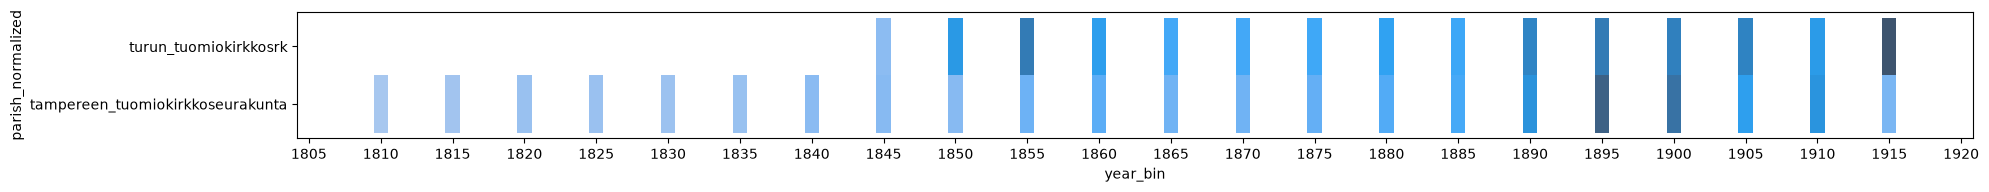

In [214]:
fig, ax = plt.subplots(figsize=(20, 2))
ax.set_xticks(range(1700, 2005, 5))
sns.histplot(
    event_year_df_binned[
        event_year_df_binned["parish_normalized"].isin(
            [
                "turun_tuomiokirkkosrk",
                "tampereen_tuomiokirkkoseurakunta"
            ]
        )
    ],
    y="parish_normalized",
    x="year_bin",
    ax=ax,
        
)
fig.tight_layout()

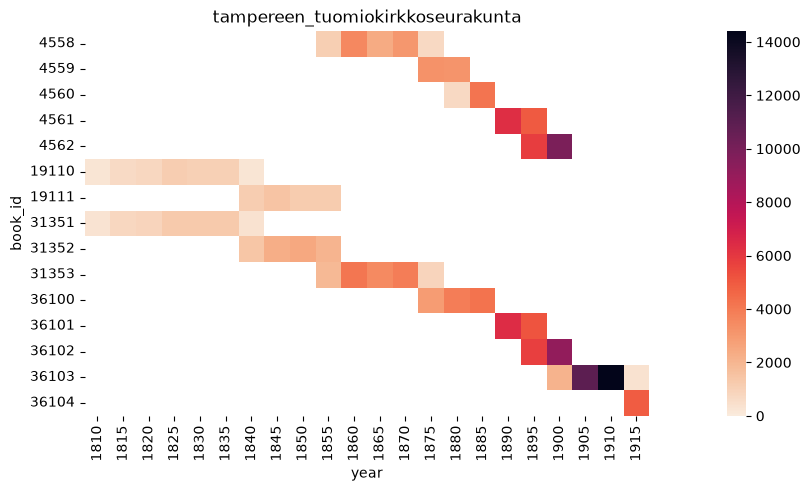

In [215]:
parish_filters = [
    "tampereen_tuomiokirkkoseurakunta",
    #"turun_tuomiokirkkosrk"
]
pivot_df = event_year_df_binned[
        event_year_df_binned["parish_normalized"].isin(parish_filters)
    ][["book_id", "year_bin", "events"]].pivot_table(
    index="book_id", columns="year_bin", values="events", aggfunc="sum", fill_value=0
)

fig, ax = plt.subplots(figsize=(20, 5))
sns.heatmap(pivot_df, cmap=sns.cm.rocket_r, mask=(pivot_df==0), square=True, vmin=0, ax=ax)
ax.set_title(", ".join(parish_filters))
ax.set_xlabel("year")
ax.set_ylabel("book_id")
plt.show()